# MeterMind — Model 2: GRU Seq2Seq with Attention

This notebook implements the **learned neural baseline** for MeterMind.

A GRU encoder-decoder with Bahdanau attention learns to compress expanded archaic prose back into metrically structured lines — purely from examples, no explicit stress rules.

### How it works
```
INPUT  : 'Thou feedest thy light own flame with fuel that is self substantial'
ENCODER: reads each word left-to-right, producing a hidden state at each step
ATTENTION: at each decoder step, learns which encoder states to focus on
DECODER: generates one word at a time, attending to the right input words
OUTPUT : 'feedest thy lights flame with self substantial fuel'
```

### Why attention?
Without attention, the encoder compresses the whole input into a single vector — a bottleneck. With attention, the decoder can look back at *all* encoder states at each step, learning which input word belongs at each output position. This maps naturally onto the reordering task.

### Pipeline
```
training_pairs.csv → vocab → GRU+attention → train → evaluate (MA, SP, G)
```

## 0. Install dependencies

In [ ]:
%pip install pronouncing sentence-transformers torch transformers --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 10.6 MB/s eta 0:00:00


## 1. Imports & configuration

In [ ]:
import re, io, csv, math, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from google.colab import files
from sentence_transformers import SentenceTransformer, util
import pronouncing

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
# Automatically uses GPU if available (Colab provides a free T4)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Hyperparameters ───────────────────────────────────────────────────────────
MAX_LEN    = 30     # max sequence length (words)
EMBED_DIM  = 128    # word embedding size
HIDDEN_DIM = 256    # GRU hidden state size
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 0.001
CLIP       = 1.0    # gradient clipping to prevent exploding gradients
TEACHER_FORCING_RATIO = 0.5  # probability of using ground truth token during training

print('Config ready.')

Using device: cpu
Config ready.


## 2. Load dataset

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

pairs = list(zip(df['input'].tolist(), df['target'].tolist()))
random.shuffle(pairs)

# Train / val / test split — split on unique targets so no target leaks across splits
unique_targets = sorted({t for _, t in pairs})
random.shuffle(unique_targets)
n = len(unique_targets)
train_targets = set(unique_targets[:int(n * 0.8)])
val_targets   = set(unique_targets[int(n * 0.8):int(n * 0.9)])
test_targets  = set(unique_targets[int(n * 0.9):])

train_pairs = [(s, t) for s, t in pairs if t in train_targets]
val_pairs   = [(s, t) for s, t in pairs if t in val_targets]
test_pairs  = [(s, t) for s, t in pairs if t in test_targets]

print(f'Total pairs : {len(pairs):,}')
print(f'Train       : {len(train_pairs):,}')
print(f'Val         : {len(val_pairs):,}')
print(f'Test        : {len(test_pairs):,}')
print(f'\nExample:')
print(f'  INPUT  : {pairs[0][0]}')
print(f'  TARGET : {pairs[0][1]}')

Saving training_pairs.csv to training_pairs.csv
Total pairs : 1,455
Train       : 1,164
Val         : 144
Test        : 147

Example:
  INPUT  : Tan sacred beauty doth blunt the sharpest intents, that which is most hallowed in appearance.
  TARGET : Tan sacred beauty, blunt the sharpest intents,


## 3. Vocabulary

We build a word-level vocabulary from all training pairs.
Four special tokens:
- `<PAD>` — padding to make sequences the same length in a batch
- `<SOS>` — start of sequence signal to the decoder
- `<EOS>` — end of sequence, tells decoder to stop
- `<UNK>` — unknown word (fallback for words not seen in training)

In [ ]:
def tokenize(text):
    """Lowercase, strip punctuation, split into word tokens."""
    return re.sub(r"[^a-zA-Z\s]", "", text.lower()).split()


def build_vocab(pairs):
    vocab = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
    for src, tgt in pairs:
        for word in tokenize(src) + tokenize(tgt):
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab


def encode(words, vocab, max_len):
    """Convert word list to padded integer sequence with SOS and EOS."""
    ids = [vocab['<SOS>']] + [vocab.get(w, vocab['<UNK>']) for w in words] + [vocab['<EOS>']]
    ids = ids[:max_len]
    return ids + [vocab['<PAD>']] * (max_len - len(ids))


# Build vocab from training pairs only (no data leakage)
vocab        = build_vocab(train_pairs)
idx_to_word  = {v: k for k, v in vocab.items()}
VOCAB_SIZE   = len(vocab)

print(f'Vocabulary size: {VOCAB_SIZE:,}')

Vocabulary size: 2,377


## 4. Dataset & DataLoader

In [ ]:
class PoetryDataset(Dataset):
    """
    Each item returns:
      src     : encoded input (expanded prose)
      tgt_in  : encoded target with SOS (decoder input)
      tgt_out : encoded target with EOS (what the decoder should predict)
    """
    def __init__(self, pairs, vocab, max_len):
        self.pairs   = pairs
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]
        src = encode(tokenize(src_text), self.vocab, self.max_len)
        tgt = encode(tokenize(tgt_text), self.vocab, self.max_len)
        src = torch.tensor(src, dtype=torch.long)
        tgt = torch.tensor(tgt, dtype=torch.long)
        return src, tgt[:-1], tgt[1:]   # tgt_in (SOS...), tgt_out (...EOS)


train_loader = DataLoader(PoetryDataset(train_pairs, vocab, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(PoetryDataset(val_pairs,   vocab, MAX_LEN), batch_size=BATCH_SIZE)
test_loader  = DataLoader(PoetryDataset(test_pairs,  vocab, MAX_LEN), batch_size=BATCH_SIZE)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 37
Val batches   : 5
Test batches  : 5


## 5. Model architecture

### Encoder
A GRU that reads the input word by word, producing:
- `encoder_outputs` — hidden state at every time step (used by attention)
- `hidden` — final hidden state (used to initialise the decoder)

### Attention (Bahdanau)
At each decoder step, attention computes a score between the current decoder hidden state and every encoder output. These scores are softmaxed into weights, then used to build a **context vector** — a weighted sum of encoder outputs. Intuitively: "given where I am in decoding, which input words should I focus on?"

### Decoder
At each step the decoder takes:
1. The previous output word (or `<SOS>` at the start)
2. The context vector from attention
3. Its own previous hidden state
...and predicts the next output word.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(0.3)

    def forward(self, src):
        # src: [batch, seq_len]
        embedded = self.dropout(self.embedding(src))        # [batch, seq_len, embed_dim]
        outputs, hidden = self.gru(embedded)                # outputs: [batch, seq_len, hidden_dim]
        return outputs, hidden


class BahdanauAttention(nn.Module):
    """
    Computes attention weights over encoder outputs.
    score(decoder_hidden, encoder_output) = v * tanh(W1*decoder + W2*encoder)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden  : [batch, hidden_dim]
        # encoder_outputs : [batch, src_len, hidden_dim]
        dec = self.W1(decoder_hidden).unsqueeze(1)          # [batch, 1, hidden_dim]
        enc = self.W2(encoder_outputs)                      # [batch, src_len, hidden_dim]
        scores = self.v(torch.tanh(dec + enc)).squeeze(-1)  # [batch, src_len]
        weights = F.softmax(scores, dim=-1)                 # [batch, src_len]
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [batch, hidden_dim]
        return context, weights


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(hidden_dim)
        # Input to GRU = embedding + context vector
        self.gru       = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out    = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(0.3)

    def forward(self, tgt_token, hidden, encoder_outputs):
        # tgt_token      : [batch] — single token at this step
        # hidden         : [1, batch, hidden_dim]
        # encoder_outputs: [batch, src_len, hidden_dim]
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))  # [batch, 1, embed_dim]
        context, attn_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        gru_input = torch.cat([embedded, context.unsqueeze(1)], dim=-1)  # [batch, 1, embed+hidden]
        output, hidden = self.gru(gru_input, hidden)                     # [batch, 1, hidden_dim]
        logits = self.fc_out(output.squeeze(1))                          # [batch, vocab_size]
        return logits, hidden, attn_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, hidden_dim)
        self.decoder = Decoder(vocab_size, embed_dim, hidden_dim)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        Teacher forcing: during training, feed the ground-truth token as
        decoder input with probability `teacher_forcing_ratio`.
        This speeds up learning by keeping the decoder on track early in training.
        """
        batch_size, tgt_len = tgt.shape
        encoder_outputs, hidden = self.encoder(src)

        # First decoder input is always <SOS>
        dec_input = tgt[:, 0]
        all_logits = []

        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder(dec_input, hidden, encoder_outputs)
            all_logits.append(logits.unsqueeze(1))
            # Teacher forcing decision
            if random.random() < teacher_forcing_ratio:
                dec_input = tgt[:, t]           # use ground truth
            else:
                dec_input = logits.argmax(-1)   # use model prediction

        return torch.cat(all_logits, dim=1)  # [batch, tgt_len-1, vocab_size]


model     = Seq2SeqAttention(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore PAD tokens in loss

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

Model parameters: 2,140,745


## 6. Training

In [ ]:
def run_epoch(model, loader, optimizer=None, teacher_forcing_ratio=0.5):
    """Run one epoch. If optimizer is None, runs in eval mode (no gradients)."""

    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0

    with torch.set_grad_enabled(is_train):

        for src, tgt_in, tgt_out in loader:

            src = src.to(DEVICE)
            tgt_in = tgt_in.to(DEVICE)
            tgt_out = tgt_out.to(DEVICE)

            logits = model(src, tgt_in, teacher_forcing_ratio)

            # ensure same sequence length
            min_len = min(logits.size(1), tgt_out.size(1))

            logits = logits[:, :min_len, :]
            tgt_out = tgt_out[:, :min_len]

            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                tgt_out.reshape(-1)
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    CLIP
                )

                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)

## 12. Ablation 1 — Attention vs No Attention

Train a plain GRU encoder-decoder **without** Bahdanau attention using identical
hyperparameters. Comparing against the full model isolates the contribution of attention
on the reordering task.

> **Hypothesis:** attention improves MA by letting the decoder focus on the correct
> input word at each position. SP and G should be similar since both variants share
> the copy mask at inference.

Epoch  10/50  Train: 3.9536  Val: 6.5731
Epoch  20/50  Train: 1.5172  Val: 7.1421
Epoch  30/50  Train: 0.3738  Val: 7.9250
Epoch  40/50  Train: 0.0900  Val: 8.6815
Epoch  50/50  Train: 0.0466  Val: 8.5545
Best plain val loss: 6.1363


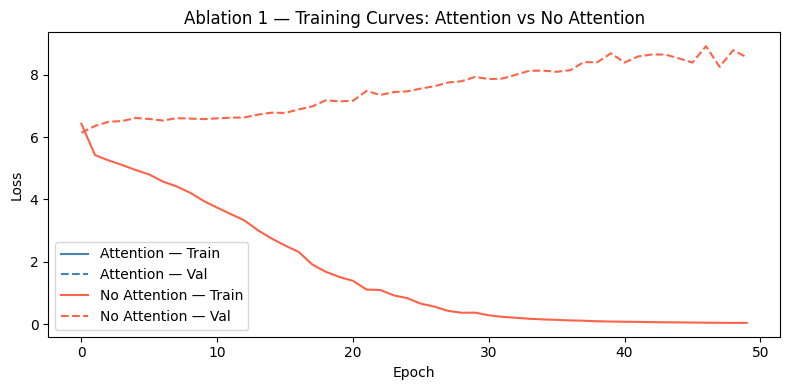

In [ ]:
# ══ ABLATION 1: Plain GRU (no attention) ═══════════════════════════════════════

class PlainDecoder(nn.Module):
    """Decoder without attention — uses only encoder final hidden state."""
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out    = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(0.3)

    def forward(self, tgt_token, hidden, encoder_outputs):
        # encoder_outputs ignored — no attention
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))
        output, hidden = self.gru(embedded, hidden)
        logits = self.fc_out(output.squeeze(1))
        # Return dummy weights (zeros) to keep interface consistent with Decoder
        dummy_weights = torch.zeros(
            tgt_token.size(0), encoder_outputs.size(1)
        ).to(tgt_token.device)
        return logits, hidden, dummy_weights


class PlainSeq2Seq(nn.Module):
    """GRU seq2seq WITHOUT attention — identical encoder, no-attention decoder."""
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, hidden_dim)
        self.decoder = PlainDecoder(vocab_size, embed_dim, hidden_dim)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        _, tgt_len = tgt.shape  # batch_size unused
        encoder_outputs, hidden = self.encoder(src)
        dec_input  = tgt[:, 0]
        all_logits = []
        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder(dec_input, hidden, encoder_outputs)
            all_logits.append(logits.unsqueeze(1))
            if random.random() < teacher_forcing_ratio:
                dec_input = tgt[:, t]
            else:
                dec_input = logits.argmax(-1)
        return torch.cat(all_logits, dim=1)


# ── Train plain model (reuses run_epoch from §6) ────────────────────────────
plain_model     = PlainSeq2Seq(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
plain_optimizer = torch.optim.Adam(plain_model.parameters(), lr=LR)
plain_train_losses, plain_val_losses = [], []
best_plain_val = float('inf')

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(plain_model, train_loader, plain_optimizer, TEACHER_FORCING_RATIO)
    val_loss   = run_epoch(plain_model, val_loader)
    plain_train_losses.append(train_loss)
    plain_val_losses.append(val_loss)
    if val_loss < best_plain_val:
        best_plain_val = val_loss
        torch.save(plain_model.state_dict(), 'best_plain_model.pt')
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  Train: {train_loss:.4f}  Val: {val_loss:.4f}')

print(f'Best plain val loss: {best_plain_val:.4f}')

# ── Training curve comparison ────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses,       label='Attention — Train',    color='steelblue')
plt.plot(val_losses,         label='Attention — Val',      color='steelblue', linestyle='--')
plt.plot(plain_train_losses, label='No Attention — Train', color='tomato')
plt.plot(plain_val_losses,   label='No Attention — Val',   color='tomato',    linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ablation 1 — Training Curves: Attention vs No Attention')
plt.legend()
plt.tight_layout()
plt.savefig('ablation1_training_curves.png', dpi=150)
plt.show()


## 7. Inference

Two constraints applied at inference time:
1. **Copy mask** — model can only output words present in the source input (since all target words are guaranteed to be there by dataset construction)
2. **Repetition penalty** — reduces the score of already-used tokens so the model doesn't repeat words

In [ ]:
torch.save(model.state_dict(), 'best_model.pt')

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()


def get_source_mask(src_ids, vocab_size):
    """Allow only tokens present in the source. Always allow EOS so model can stop."""
    mask = torch.full((vocab_size,), float('-inf'))
    for token_id in src_ids:
        if token_id not in (0, 1, 2, 3):  # skip PAD, SOS, EOS, UNK
            mask[token_id] = 0.0
    mask[vocab['<EOS>']] = 0.0
    return mask.to(DEVICE)


def predict(src_text, max_len=MAX_LEN, repeat_penalty=2.0):
    src_ids  = encode(tokenize(src_text), vocab, max_len)
    src      = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    src_mask = get_source_mask(src_ids, VOCAB_SIZE)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)

    dec_input  = torch.tensor([vocab['<SOS>']], dtype=torch.long).to(DEVICE)
    output_words = []
    used_tokens  = set()

    for _ in range(max_len):
        with torch.no_grad():
            logits, hidden, _ = model.decoder(dec_input, hidden, encoder_outputs)

        logits = logits.squeeze(0) + src_mask
        for tok in used_tokens:
            logits[tok] -= repeat_penalty

        next_token = logits.argmax().item()
        if next_token == vocab['<EOS>']:
            break

        word = idx_to_word.get(next_token, '<UNK>')
        output_words.append(word)
        used_tokens.add(next_token)
        dec_input = torch.tensor([next_token], dtype=torch.long).to(DEVICE)

    return ' '.join(output_words)


# Quick sample
print('Sample predictions:\n')
for src, tgt in test_pairs[:3]:
    out = predict(src)
    print(f'INPUT  : {src}')
    print(f'TARGET : {tgt}')
    print(f'OUTPUT : {out}')
    print()

Sample predictions:

INPUT  : Which did erst canopy the herd from heat, as a protective shelter doth.
TARGET : Which erst from heat did canopy the herd,
OUTPUT : the as a

INPUT  : And right perfection, which hath been wrongfully disgraced by villainous hands
TARGET : And right perfection wrongfully disgraced,
OUTPUT : and by hath

INPUT  : The weary night doth claim my heavy eyelids, and to it shall they fall?
TARGET : My heavy eyelids to the weary night?
OUTPUT : and the to my



## 8. Evaluation metrics

In [ ]:
# ── Shared metric utilities ───────────────────────────────────────────────────
# Upload meter_utils.py then eval_metrics.py when prompted.
from google.colab import files as _fu
print('Please upload meter_utils.py')
_fu.upload()
from meter_utils import *
print('Please upload eval_metrics.py')
_fu.upload()
from eval_metrics import *

# Trigger model downloads before the eval loop
load_sp_model()
load_gpt2()
print('All metrics ready.')


Please upload meter_utils.py


Saving meter_utils.py to meter_utils.py
Please upload eval_metrics.py


Saving eval_metrics.py to eval_metrics.py
Loading SentenceTransformer (first run downloads ~90 MB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

All metrics ready.


## 9. Evaluate on test set

In [ ]:
# ── Step 1 & 2: Inference + Metrical Accuracy ────────────────────────────────
from tqdm.notebook import tqdm

rows = []
for src_text, tgt_text in tqdm(test_pairs, desc='Inference + MA'):
    output = predict(src_text)
    words  = tokenize(output)
    rows.append({
        'input':  src_text,
        'target': tgt_text,
        'output': output,
        'MA':     round(metrical_accuracy(words), 4),
    })
print(f'{len(rows):,} predictions done.')


Inference + MA:   0%|          | 0/147 [00:00<?, ?it/s]

147 predictions done.


In [ ]:
# ── Step 3: Semantic Preservation (batched encode) ────────────────────────────
from sentence_transformers import util

inputs_clean  = [' '.join(tokenize(r['input'])) for r in rows]
outputs_clean = [r['output'] for r in rows]

print(f'Encoding {len(rows):,} input+output pairs...')
embs = load_sp_model().encode(
    inputs_clean + outputs_clean,
    convert_to_tensor=True,
    show_progress_bar=True,
)

n = len(rows)
for i, r in enumerate(rows):
    r['SP'] = round(float(max(0.0, util.cos_sim(embs[i], embs[n + i]))), 4)

print('SP done.')


Encoding 147 input+output pairs...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

SP done.


In [ ]:
# ── Step 4: Grammaticality (batched GPT-2, per-sequence loss) ─────────────────
import torch, math
from tqdm.notebook import tqdm as tqdm_nb

BATCH_SIZE = 32
gpt2_model, gpt2_tok = load_gpt2()

if gpt2_tok.pad_token_id is None:
    gpt2_tok.pad_token_id = gpt2_tok.eos_token_id

outputs_list = [r['output'] for r in rows]
g_scores     = []

for batch_start in tqdm_nb(range(0, len(outputs_list), BATCH_SIZE), desc='Grammaticality'):
    batch = outputs_list[batch_start : batch_start + BATCH_SIZE]
    enc   = gpt2_tok(batch, return_tensors='pt', padding=True,
                     truncation=True, max_length=128)
    input_ids = enc['input_ids']
    labels    = input_ids.clone()
    labels[input_ids == gpt2_tok.pad_token_id] = -100

    with torch.no_grad():
        logits = gpt2_model(**enc).logits

    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    loss_fn      = torch.nn.CrossEntropyLoss(ignore_index=-100, reduction='none')
    token_losses = loss_fn(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
    ).view(len(batch), -1)
    mask       = (shift_labels != -100).float()
    seq_losses = (token_losses * mask).sum(-1) / mask.sum(-1).clamp(min=1)

    for loss_val in seq_losses.tolist():
        g_scores.append(round(1 / (1 + math.log(math.exp(loss_val))), 4))

for r, g in zip(rows, g_scores):
    r['G'] = g

print(f'G done. {len(g_scores):,} scores computed.')


Grammaticality:   0%|          | 0/5 [00:00<?, ?it/s]

G done. 147 scores computed.


In [ ]:
# ── Step 5: Assemble results DataFrame ───────────────────────────────────────
results_df = pd.DataFrame(rows)
print(f'Evaluated {len(results_df):,} test pairs.')


Evaluated 147 test pairs.


Evaluating plain GRU:   0%|          | 0/147 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



=== Ablation 1: Attention vs No Attention ===
Metric   With Attention  Without Attention    Delta
----------------------------------------------------
MA               0.3333             0.3000  +0.0333  (+attn wins)
SP               0.2475             0.2470  +0.0005  (+attn wins)
G                0.1296             0.1314  -0.0019  (-attn wins)


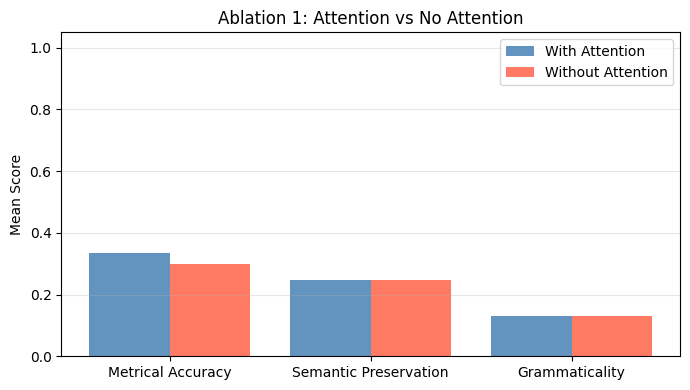

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ablation 1 complete.


In [ ]:
# ── Evaluate plain model on test set ────────────────────────────────────────
# Run after §9 so results_df and metric functions are already available.
plain_model.load_state_dict(torch.load('best_plain_model.pt', map_location=DEVICE))
plain_model.eval()

plain_results = []
for src_text, tgt_text in tqdm(test_pairs, desc='Evaluating plain GRU'):
    src_ids  = encode(tokenize(src_text), vocab, MAX_LEN)
    src      = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    src_mask = get_source_mask(src_ids, VOCAB_SIZE)

    with torch.no_grad():
        enc_out, hidden = plain_model.encoder(src)

    dec_input    = torch.tensor([vocab['<SOS>']], dtype=torch.long).to(DEVICE)
    output_words = []
    used_tokens  = set()

    for _ in range(MAX_LEN):
        with torch.no_grad():
            logits, hidden, _ = plain_model.decoder(dec_input, hidden, enc_out)
        logits = logits.squeeze(0) + src_mask
        for tok in used_tokens:
            logits[tok] -= 2.0
        next_token = logits.argmax().item()
        if next_token == vocab['<EOS>']:
            break
        output_words.append(idx_to_word.get(next_token, '<UNK>'))
        used_tokens.add(next_token)
        dec_input = torch.tensor([next_token], dtype=torch.long).to(DEVICE)

    output = ' '.join(output_words)
    words  = tokenize(output)
    plain_results.append({
        'input':  src_text,
        'target': tgt_text,
        'output': output,
        'MA': round(metrical_accuracy(words), 4),
        'SP': round(semantic_preservation(' '.join(tokenize(src_text)), output), 4),
        'G':  round(grammaticality(output), 4),
    })

plain_df = pd.DataFrame(plain_results)

# ── Side-by-side table ───────────────────────────────────────────────────────
print('\n=== Ablation 1: Attention vs No Attention ===')
print(f"{'Metric':<6} {'With Attention':>16} {'Without Attention':>18} {'Delta':>8}")
print('-' * 52)
for metric in ['MA', 'SP', 'G']:
    with_att    = results_df[metric].mean()
    without_att = plain_df[metric].mean()
    delta       = with_att - without_att
    direction   = '(+attn wins)' if delta > 0 else '(-attn wins)'
    print(f"{metric:<6} {with_att:>16.4f} {without_att:>18.4f} {delta:>+8.4f}  {direction}")

# ── Bar chart ────────────────────────────────────────────────────────────────
metrics      = ['MA', 'SP', 'G']
x            = range(len(metrics))
with_vals    = [results_df[m].mean() for m in metrics]
without_vals = [plain_df[m].mean()   for m in metrics]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - 0.2 for i in x], with_vals,    0.4, label='With Attention',    color='steelblue', alpha=0.85)
ax.bar([i + 0.2 for i in x], without_vals, 0.4, label='Without Attention', color='tomato',    alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(['Metrical Accuracy', 'Semantic Preservation', 'Grammaticality'])
ax.set_ylabel('Mean Score')
ax.set_ylim(0, 1.05)
ax.set_title('Ablation 1: Attention vs No Attention')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ablation1_attention_comparison.png', dpi=150)
plt.show()

plain_df.to_csv('ablation1_no_attention_results.csv', index=False)
files.download('ablation1_no_attention_results.csv')
files.download('ablation1_training_curves.png')
files.download('ablation1_attention_comparison.png')
print('Ablation 1 complete.')


## 13. Ablation 2 — Copy Mask On vs Off

Re-run inference on the **already-trained** model without the copy mask.
No retraining needed — this tests whether the hard vocabulary constraint is
earning its keep.

> **Hypothesis:** the mask improves SP by keeping the decoder grounded in source
> words, possibly at the cost of G (constrained vocabulary → less fluent outputs).
> If SP collapses without the mask, the constraint is essential.

In [ ]:
from tqdm.notebook import tqdm

Evaluating (no mask):   0%|          | 0/147 [00:00<?, ?it/s]


=== Ablation 2: Copy Mask On vs Off ===
Metric    With Mask   Without Mask    Delta
--------------------------------------------
MA           0.3333         0.5000  -0.1667  (-mask wins)
SP           0.2475         0.2733  -0.0258  (-mask wins)
G            0.1296         0.1120  +0.0176  (+mask wins)


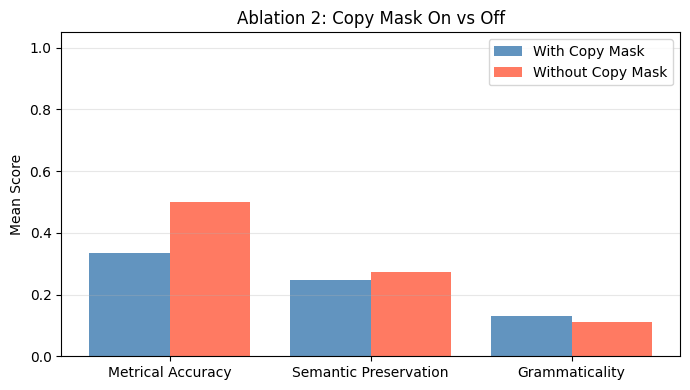

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ablation 2 complete.


In [ ]:
# ══ ABLATION 2: Copy Mask On vs Off ════════════════════════════════════════════
# results_df (WITH mask) from §9 is the baseline — no retraining needed.

def predict_no_mask(src_text, repeat_penalty=2.0):
    """Inference WITHOUT copy mask — model can output any vocabulary word."""
    src_ids = encode(tokenize(src_text), vocab, MAX_LEN)
    src     = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)

    dec_input    = torch.tensor([vocab['<SOS>']], dtype=torch.long).to(DEVICE)
    output_words = []
    used_tokens  = set()

    for _ in range(MAX_LEN):
        with torch.no_grad():
            logits, hidden, _ = model.decoder(dec_input, hidden, encoder_outputs)
        logits = logits.squeeze(0)
        # No source mask — model can generate any word in vocab
        for tok in used_tokens:
            logits[tok] -= repeat_penalty
        # Block special tokens only
        for special in [vocab['<PAD>'], vocab['<SOS>'], vocab['<UNK>']]:
            logits[special] = float('-inf')
        next_token = logits.argmax().item()
        if next_token == vocab['<EOS>']:
            break
        output_words.append(idx_to_word.get(next_token, '<UNK>'))
        used_tokens.add(next_token)
        dec_input = torch.tensor([next_token], dtype=torch.long).to(DEVICE)

    return ' '.join(output_words)


# ── Run inference without mask ───────────────────────────────────────────────
no_mask_results = []
for src_text, tgt_text in tqdm(test_pairs, desc='Evaluating (no mask)'):
    output = predict_no_mask(src_text)
    words  = tokenize(output)
    no_mask_results.append({
        'input':  src_text,
        'target': tgt_text,
        'output': output,
        'MA': round(metrical_accuracy(words), 4),
        'SP': round(semantic_preservation(' '.join(tokenize(src_text)), output), 4),
        'G':  round(grammaticality(output), 4),
    })

no_mask_df = pd.DataFrame(no_mask_results)

# ── Side-by-side table ───────────────────────────────────────────────────────
print('\n=== Ablation 2: Copy Mask On vs Off ===')
print(f"{'Metric':<6} {'With Mask':>12} {'Without Mask':>14} {'Delta':>8}")
print('-' * 44)
for metric in ['MA', 'SP', 'G']:
    with_mask    = results_df[metric].mean()
    without_mask = no_mask_df[metric].mean()
    delta        = with_mask - without_mask
    direction    = '(+mask wins)' if delta > 0 else '(-mask wins)'
    print(f"{metric:<6} {with_mask:>12.4f} {without_mask:>14.4f} {delta:>+8.4f}  {direction}")

# ── Bar chart ────────────────────────────────────────────────────────────────
metrics      = ['MA', 'SP', 'G']
x            = range(len(metrics))
with_vals    = [results_df[m].mean()  for m in metrics]
without_vals = [no_mask_df[m].mean()  for m in metrics]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - 0.2 for i in x], with_vals,    0.4, label='With Copy Mask',    color='steelblue', alpha=0.85)
ax.bar([i + 0.2 for i in x], without_vals, 0.4, label='Without Copy Mask', color='tomato',    alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(['Metrical Accuracy', 'Semantic Preservation', 'Grammaticality'])
ax.set_ylabel('Mean Score')
ax.set_ylim(0, 1.05)
ax.set_title('Ablation 2: Copy Mask On vs Off')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ablation2_copy_mask.png', dpi=150)
plt.show()

no_mask_df.to_csv('ablation2_no_mask_results.csv', index=False)
files.download('ablation2_no_mask_results.csv')
files.download('ablation2_copy_mask.png')
print('Ablation 2 complete.')


## 10. Results

=== GRU + Attention — Test Set Results ===
Metrical Accuracy (MA)    : 0.3333 ± 0.0814
Semantic Preservation (SP): 0.2475 ± 0.1209
Grammaticality (G)        : 0.1296 ± 0.0181

=== Sample outputs ===
INPUT  : Which did erst canopy the herd from heat, as a protective shelter doth.
TARGET : Which erst from heat did canopy the herd,
OUTPUT : the as a
MA=0.300  SP=0.070  G=0.157

INPUT  : And right perfection, which hath been wrongfully disgraced by villainous hands
TARGET : And right perfection wrongfully disgraced,
OUTPUT : and by hath
MA=0.300  SP=0.358  G=0.086

INPUT  : The weary night doth claim my heavy eyelids, and to it shall they fall?
TARGET : My heavy eyelids to the weary night?
OUTPUT : and the to my
MA=0.300  SP=0.239  G=0.130

INPUT  : Time, spent in gentle numbers, passeth so idly hence, and is most foolishly consumed;
TARGET : In gentle numbers time so idly spent;
OUTPUT : and in so
MA=0.200  SP=0.227  G=0.154

INPUT  : Despise not the wrinkles that come upon thee, for this

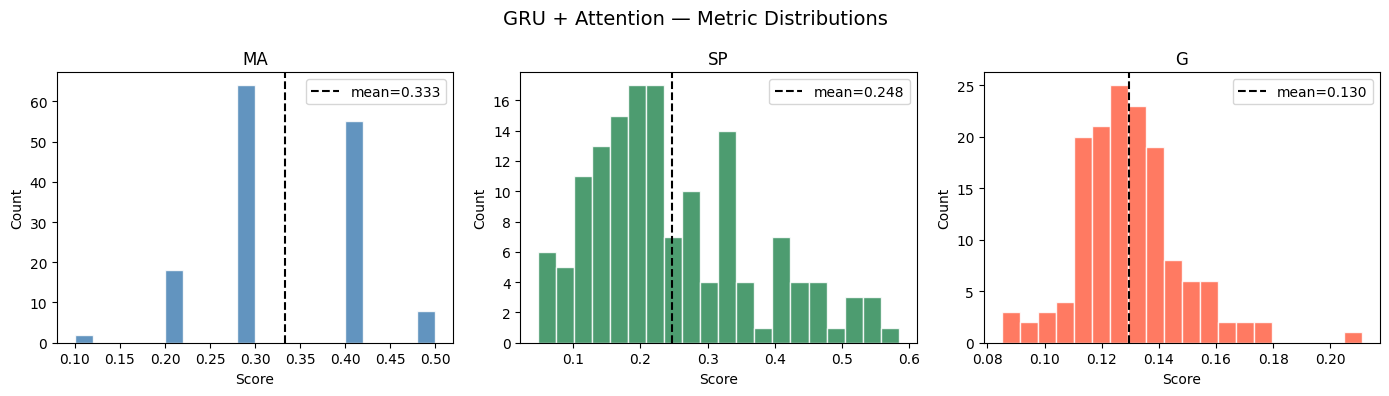

In [ ]:
print('=== GRU + Attention — Test Set Results ===')
print(f"Metrical Accuracy (MA)    : {results_df['MA'].mean():.4f} ± {results_df['MA'].std():.4f}")
print(f"Semantic Preservation (SP): {results_df['SP'].mean():.4f} ± {results_df['SP'].std():.4f}")
print(f"Grammaticality (G)        : {results_df['G'].mean():.4f} ± {results_df['G'].std():.4f}")

print('\n=== Sample outputs ===')
for _, row in results_df.head(5).iterrows():
    print(f"INPUT  : {row['input']}")
    print(f"TARGET : {row['target']}")
    print(f"OUTPUT : {row['output']}")
    print(f"MA={row['MA']:.3f}  SP={row['SP']:.3f}  G={row['G']:.3f}")
    print()

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('GRU + Attention — Metric Distributions', fontsize=14)
for ax, metric, colour in zip(axes, ['MA', 'SP', 'G'], ['steelblue', 'seagreen', 'tomato']):
    ax.hist(results_df[metric], bins=20, color=colour, edgecolor='white', alpha=0.85)
    ax.axvline(results_df[metric].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f"mean={results_df[metric].mean():.3f}")
    ax.set_title(metric)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig('gru_attention_metrics.png', dpi=150)
plt.show()

## 11. Save results

In [ ]:
results_df.to_csv('gru_attention_results.csv', index=False)
print('Saved gru_attention_results.csv')

summary = {
    'model': 'GRU + Attention',
    'n':     len(results_df),
    'MA':    {'mean': round(float(results_df['MA'].mean()), 4), 'std': round(float(results_df['MA'].std()), 4)},
    'SP':    {'mean': round(float(results_df['SP'].mean()), 4), 'std': round(float(results_df['SP'].std()), 4)},
    'G':     {'mean': round(float(results_df['G'].mean()),  4), 'std': round(float(results_df['G'].std()),  4)},
}
with open('gru_attention_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved gru_attention_summary.json')

files.download('gru_attention_results.csv')
files.download('gru_attention_summary.json')
files.download('ablation1_training_curves.png')
files.download('gru_attention_metrics.png')

Saved gru_attention_results.csv
Saved gru_attention_summary.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Mini Eval — Cross-Model Sample Comparison

Runs the full eval pipeline on a small fixed sample from the test set. Use the same `N_EVAL` and `SEED` across all three notebooks to ensure the comparison is fair.

In [ ]:
# ── Mini eval ─────────────────────────────────────────────────────────────────
import random
from tqdm.notebook import tqdm

N_EVAL = 50
SEED   = 42

random.seed(SEED)
_eval_pairs = random.sample(test_pairs, min(N_EVAL, len(test_pairs)))

# ── Step 1: Inference + MA ────────────────────────────────────────────────────
_rows = []
for _src, _tgt in tqdm(_eval_pairs, desc='GRU inference + MA'):
    _output = predict(_src)
    _words  = tokenize(_output)
    _rows.append({
        'input':  _src,
        'target': _tgt,
        'output': _output,
        'MA':     round(metrical_accuracy(_words), 4),
    })

# ── Step 2: Semantic Preservation (batched) ───────────────────────────────────
from sentence_transformers import util as _util

_inputs_clean  = [' '.join(tokenize(r['input'])) for r in _rows]
_outputs_clean = [r['output'] for r in _rows]
_embs = load_sp_model().encode(
    _inputs_clean + _outputs_clean,
    convert_to_tensor=True,
    show_progress_bar=True,
)
_n = len(_rows)
for _i, _r in enumerate(_rows):
    _r['SP'] = round(float(max(0.0, _util.cos_sim(_embs[_i], _embs[_n + _i]))), 4)

# ── Step 3: Grammaticality (batched GPT-2) ────────────────────────────────────
import torch as _torch, math as _math

_G_BATCH  = 32
_gm, _gt  = load_gpt2()
if _gt.pad_token_id is None:
    _gt.pad_token_id = _gt.eos_token_id

_out_list = [r['output'] for r in _rows]
_g_scores = []
for _bs in range(0, len(_out_list), _G_BATCH):
    _batch = _out_list[_bs : _bs + _G_BATCH]
    _enc   = _gt(_batch, return_tensors='pt', padding=True, truncation=True, max_length=128)
    _ids   = _enc['input_ids']
    _lbl   = _ids.clone()
    _lbl[_ids == _gt.pad_token_id] = -100
    with _torch.no_grad():
        _lg = _gm(**_enc).logits
    _sl = _lg[:, :-1, :].contiguous()
    _tl = _lbl[:, 1:].contiguous()
    _fn = _torch.nn.CrossEntropyLoss(ignore_index=-100, reduction='none')
    _tl2 = _fn(_sl.view(-1, _sl.size(-1)), _tl.view(-1)).view(len(_batch), -1)
    _mk = (_tl != -100).float()
    _sq = (_tl2 * _mk).sum(-1) / _mk.sum(-1).clamp(min=1)
    for _lv in _sq.tolist():
        _g_scores.append(round(1 / (1 + _lv), 4))
for _r, _g in zip(_rows, _g_scores):
    _r['G'] = _g

# ── Results ───────────────────────────────────────────────────────────────────
import pandas as _pd
_eval_df = _pd.DataFrame(_rows)
print(f"\nMini eval — {len(_eval_df)} pairs")
print(_eval_df[['MA', 'SP', 'G']].describe().round(4).to_string())
print()
for _, _row in _eval_df.head(3).iterrows():
    print(f"  INPUT  : {_row['input']}")
    print(f"  OUTPUT : {_row['output']}")
    print(f"  MA={_row['MA']:.3f}  SP={_row['SP']:.3f}  G={_row['G']:.3f}")
    print()


GRU inference + MA:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]


Mini eval — 50 pairs
            MA       SP        G
count  50.0000  50.0000  50.0000
mean    0.3260   0.2420   0.1294
std     0.0853   0.1268   0.0206
min     0.1000   0.0608   0.0912
25%     0.3000   0.1548   0.1188
50%     0.3000   0.2138   0.1266
75%     0.4000   0.3081   0.1368
max     0.5000   0.5471   0.2111

  INPUT  : It is perspective, and the very best of all painter's art, I say.
  OUTPUT : and i the of
  MA=0.400  SP=0.141  G=0.114

  INPUT  : Make thee another self, I do beseech thee, for the love of me, thy most devoted servant.
  OUTPUT : i the of for
  MA=0.300  SP=0.149  G=0.127

  INPUT  : When I do break twenty, then am I most grievously perjured.
  OUTPUT : i then when
  MA=0.300  SP=0.124  G=0.112



In [ ]:
# ── Save mini eval results ────────────────────────────────────────────────────
import json

MODEL_NAME = 'GRU Attention'   # change to 'GRU Attention' or 'Claude LLM' per notebook

_eval_df.to_csv(f'mini_{MODEL_NAME.lower().replace(" ", "_")}.csv', index=False)

_mini_summary = {
    'model': MODEL_NAME,
    'n':     len(_eval_df),
    'MA':    {'mean': round(float(_eval_df['MA'].mean()), 4), 'std': round(float(_eval_df['MA'].std()), 4)},
    'SP':    {'mean': round(float(_eval_df['SP'].mean()), 4), 'std': round(float(_eval_df['SP'].std()), 4)},
    'G':     {'mean': round(float(_eval_df['G'].mean()),  4), 'std': round(float(_eval_df['G'].std()),  4)},
}
with open(f'mini_{MODEL_NAME.lower().replace(" ", "_")}.json', 'w') as f:
    json.dump(_mini_summary, f, indent=2)

files.download(f'mini_{MODEL_NAME.lower().replace(" ", "_")}.csv')
files.download(f'mini_{MODEL_NAME.lower().replace(" ", "_")}.json')
print(f'Saved mini eval results for {MODEL_NAME}.')
So the three filenames would be mini_dp_reorderer.csv/json, mini_gru_attention.csv/json, mini_claude_llm.csv/json. The only line you change per notebook is MODEL_NAME. Want me to add this to all three now?

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved mini eval results for GRU Attention.
Object `now` not found.
